## Detecção de Fraude em Cartão de Crédito

A detecção de fraude em cartão de crédito é um processo crucial para proteger os consumidores e as instituições financeiras contra transações não autorizadas. Com o aumento das transações online, a necessidade de sistemas eficazes de detecção de fraude tornou-se ainda mais importante. Esse notebook utiliza o dataset de transações de cartão de crédito para treinar e avaliar modelos de aprendizado de máquina que podem identificar padrões suspeitos e prever a probabilidade de uma transação ser fraudulenta. O objetivo é desenvolver um modelo que possa auxiliar na prevenção de fraudes, garantindo a segurança das transações financeiras.


### Importando as bibliotecas necessárias

Aqui estão as bibliotecas que serão utilizadas para análise de dados, visualização e construção do modelo de aprendizado de máquina.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
)

### Carregamento dos dados

Nesta etapa, vamos carregar o dataset Credit Card Fraud Detection, disponível no [Kaggle](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud), para iniciar a análise exploratória e preparar os dados para o treinamento do modelo.

Algumas informações sobre o dataset:

O dataset contém transações feitas por cartões de crédito em setembro de 2013 por titulares europeus.
Este dataset apresenta transações que ocorreram em dois dias, com 492 fraudes em 284.807 transações. O conjunto é altamente desbalanceado, e a classe positiva (fraudes) representa 0,172% de todas as transações.

Ele contém apenas variáveis de entrada numéricas, resultantes de uma transformação PCA. Infelizmente, devido a questões de confidencialidade, não podemos fornecer as features originais nem mais informações de contexto sobre os dados. As features V1, V2, … V28 são os componentes principais obtidos com PCA. As únicas features que não foram transformadas por PCA são 'Time' e 'Amount'. A feature 'Time' contém os segundos decorridos entre cada transação e a primeira transação do dataset. A feature 'Amount' é o valor da transação e pode ser usada, por exemplo, em aprendizagem sensível a custo por instância.

Dada a taxa de desbalanceamento de classes, recomendamos medir a acurácia usando a Área Sob a Curva de Precisão-Revocação (AUPRC). A acurácia da matriz de confusão não é significativa para a classificação desbalanceada.

Fonte: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud/data


In [2]:
df = pd.read_csv('creditcard.csv')

### Inspeção inicial dos dados

Além disso, vamos realizar uma inspeção inicial dos dados para entender melhor a estrutura do dataset, identificar possíveis problemas e preparar os dados para o próximo passo do processo de modelagem.


In [3]:
# 0 = normal, 1 = fraude (convenção do dataset)
print(f"Formato do dataset: {df.shape[0]} amostras, {df.shape[1]-1} features")
df.head()

Formato do dataset: 284807 amostras, 30 features


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Conclusão

A saída de `df.head()` confirma que o conjunto possui 31 colunas, sendo a variável alvo `Class` o alvo da tarefa de classificação e será removida para não haver vazamento de dados. As demais features numéricas serão usadas como entrada do modelo.


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

### Conclusão

A saída de `df.info()` mostra que não há valores nulos no dataset, o que é um bom indicativo de que os dados estão completos e prontos para análise. Todas as variáveis são do tipo float64, não necessitando de nenhuma conversão de tipo.


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


### Conclusão

A saída de `df.describe()` mostra que as features possuem diferentes escalas e distribuições, o que pode impactar o desempenho do modelo. Portanto, será necessário aplicar técnicas de normalização ou padronização para garantir que todas as features contribuam de maneira equilibrada para o treinamento do modelo.

Além disso, a média e a mediana da variável `Class` indicam que o dataset é altamente desbalanceado, com a grande maioria das transações sendo legítimas. Isso reforça a necessidade de utilizar métricas apropriadas para avaliação do modelo, como AUPRC, em vez de acurácia.

A variável `Amount` apresenta uma grande variação nos valores, o que pode indicar que transações de diferentes magnitudes podem ter diferentes probabilidades de serem fraudulentas. Isso sugere que a feature `Amount` pode ser relevante para a detecção de fraudes e deve ser considerada no modelo e sua escala de valores deve ser modificada.


### EDA - heatmap de correlação

Aqui vamos criar um heatmap de correlação para visualizar as relações entre as variáveis do dataset. Isso nos ajudará a identificar quais características podem ser mais relevantes para a detecção de fraudes e como elas se relacionam entre si.


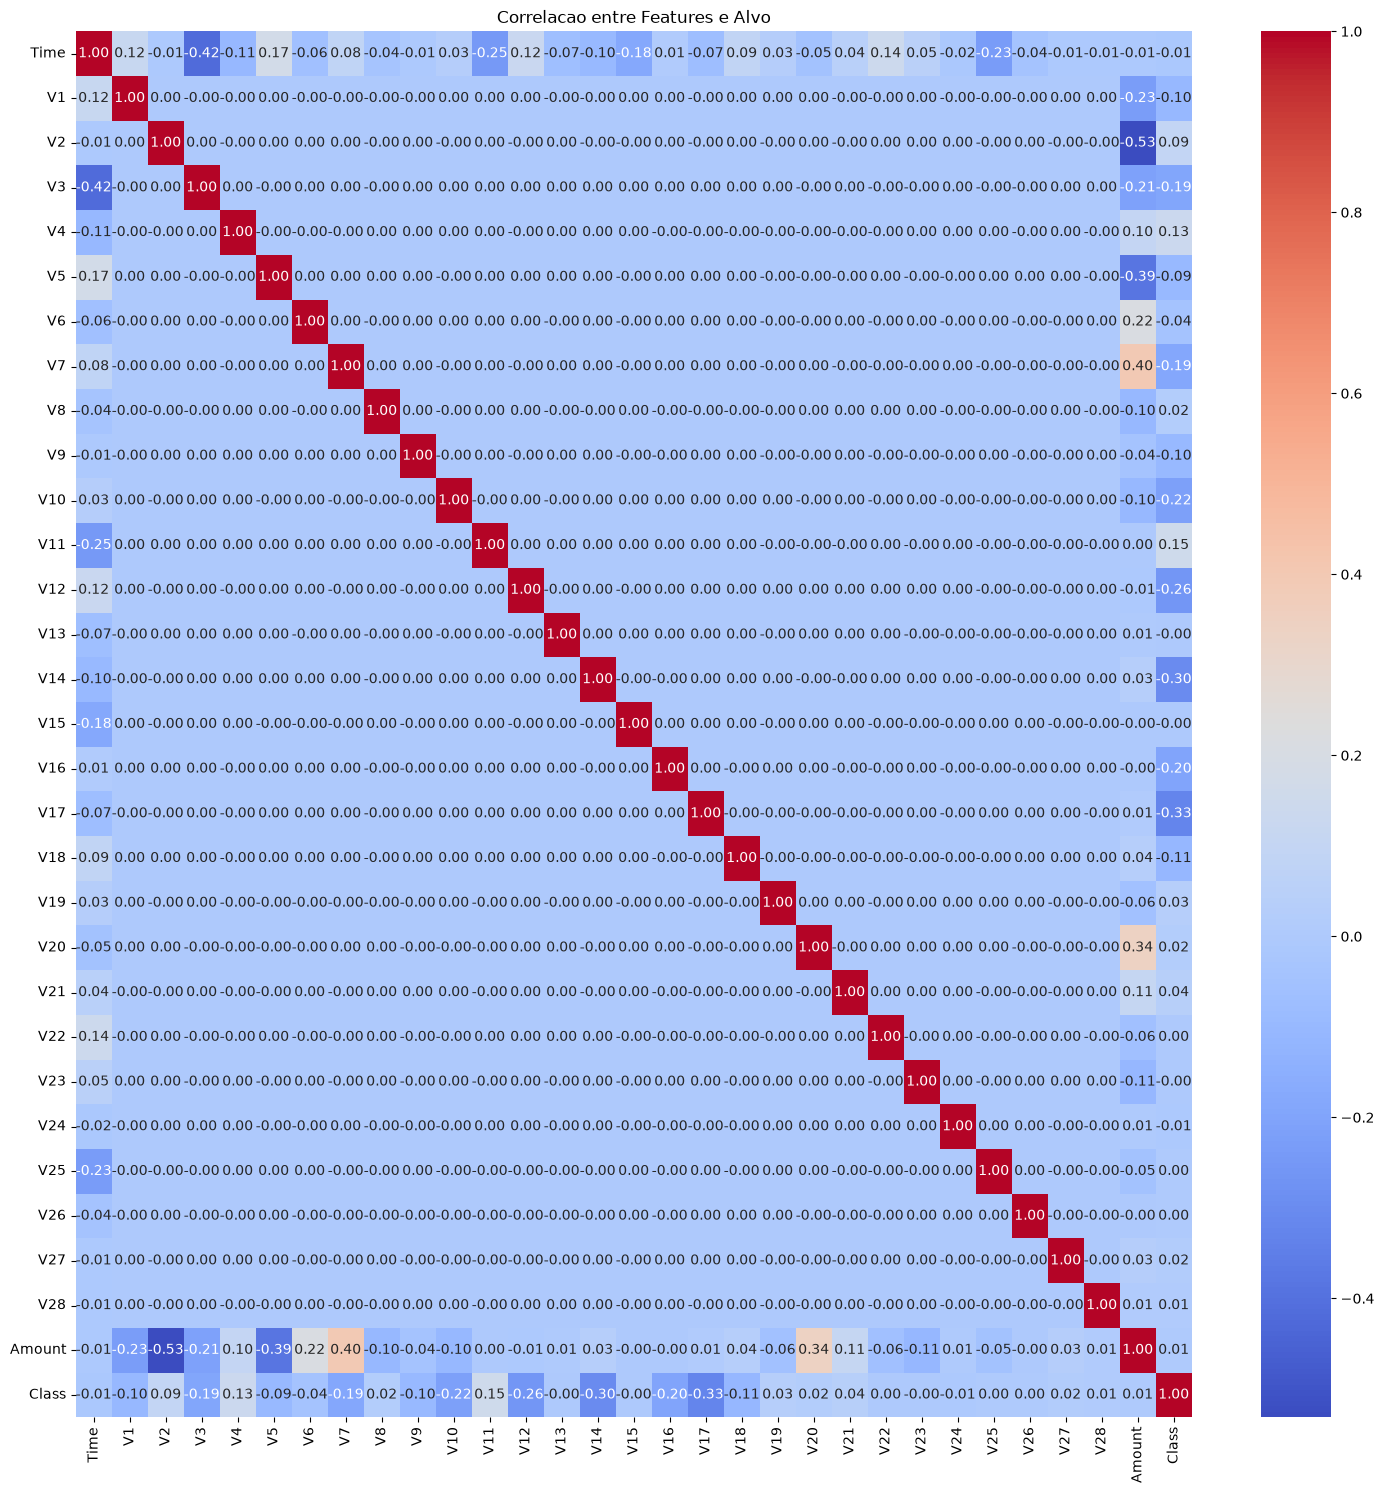

In [6]:
# Célula 3: EDA - heatmap de correlacao
plt.figure(figsize=(18, 18))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlacao entre Features e Alvo')
plt.show()

### Conclusão

A análise do heatmap de correlação revela que a maioria das features não apresenta correlação significativa com a variável alvo `Class`. Isso sugere que a detecção de fraudes pode ser um desafio, pois as transações fraudulentas não seguem padrões claros em relação às demais variáveis. Ainda assim, algumas features apresentam correlações moderadas com `Class`, como `V17`, `V14`, `V12` e `V10` (negativas) e `V16`, `V11` e `V4` (positivas), o que pode ser explorado para melhorar o desempenho do modelo. Como a proposta do exercício é utilizar todas as features, nenhuma delas será removida. Já a variável `Amount` apresenta correlação praticamente nula com `Class` (≈0.01), sugerindo que, isoladamente, o valor da transação tem pouco poder discriminativo, o que motiva transformá-la (como na escala logarítmica) em vez de descartá-la.


### Modificação da escala de `Amount` para escala logarítmica

O objetivo dessa etapa é reduzir a assimetria da variável `Amount` e comprimir valores muito altos, o que costuma ajudar modelos como regressão logística. Também vale notar que, depois dessa linha, a coluna original `Amount` deixa de existir no df, sendo substituída por `Log Amount`.

A célula abaixo faz uma transformação da variável Amount para escala logarítmica e depois atualiza a visão estatística do DataFrame.

Em resumo:

`df.pop('Amount')` remove a coluna Amount do DataFrame e retorna seus valores.

`np.log(df.pop('Amount')+eps)` aplica log natural nesses valores.

`eps = 0.001` evita problemas com valores muito pequenos ou zero, porque log(0) não é definido.

O resultado é salvo em uma nova coluna chamada `Log Amount`.

`df.describe().T` mostra um resumo estatístico das colunas já com essa nova transformação, transposto para ficar mais legível.


In [7]:
eps = 0.001
df['Log Amount'] = np.log(df.pop('Amount')+eps)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


### Divisão do dataset em treino e teste

Foram utilizados 80% dos dados para treino e 20% para teste, garantindo que a proporção de classes seja mantida em ambos os conjuntos. A divisão estratificada é importante para evitar que o modelo seja treinado com um conjunto de dados desbalanceado, o que poderia levar a um desempenho ruim na tarefa de classificação.


In [8]:
# Célula 4: Separar X/y e dividir
X = df.drop('Class', axis=1)
y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y,)

print("Treino:", X_train.shape, "| Teste:", X_test.shape)
print("Proporção de fraudes (treino):", round(y_train.mean(), 3))
print("Proporção de fraudes (teste): ", round(y_test.mean(), 3))

Treino: (227845, 30) | Teste: (56962, 30)
Proporção de fraudes (treino): 0.002
Proporção de fraudes (teste):  0.002


### Padronização dos dados e treinamento do modelo

A padronização de conjuntos de dados é um requisito comum para muitos estimadores de aprendizado de máquina implementados no scikit-learn; eles podem apresentar um mau desempenho se as features (atributos) individuais não se assemelharem, de certa forma, a dados com distribuição normal padrão: Gaussiana com média zero e variância unitária.

Na prática, frequentemente ignoramos a forma da distribuição e apenas transformamos os dados para centralizá-los, removendo o valor médio de cada feature, e então os escalonamos dividindo as features não constantes pelo seu desvio padrão.

Por exemplo, muitos elementos utilizados na função objetivo de um algoritmo de aprendizado (como o kernel RBF de Máquinas de Vetores de Suporte ou os regularizadores L1 e L2 de modelos lineares) podem assumir que todas as features estão centralizadas em zero ou possuem variância na mesma ordem de grandeza. Se uma feature tiver uma variância com ordens de grandeza maior que as demais, ela pode dominar a função objetivo e tornar o estimador incapaz de aprender corretamente com as outras features, como seria esperado.

Fonte: https://scikit-learn.org/stable/modules/preprocessing.html


In [9]:
# Célula 5: Treinar o modelo (O scaler ficará dentro do Pipeline para evitar vazamento de dados)
lr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced',
    )),
]).fit(X_train, y_train)

# Célula 6: Avaliar o modelo
pred = lr_model.predict(X_test)
pred_prob = lr_model.predict_proba(X_test)[:, 1]

print("--- Regressão Logística ---")
print(f"Acurácia:   {accuracy_score(y_test, pred):.4f}")
print(f"Precisão:   {precision_score(y_test, pred, zero_division=0):.4f}")
print(f"Revocação:  {recall_score(y_test, pred, zero_division=0):.4f}")
print(f"F1-score:   {f1_score(y_test, pred, zero_division=0):.4f}")
print(f"ROC-AUC:    {roc_auc_score(y_test, pred_prob):.4f}")
print(f"AUPRC:      {average_precision_score(y_test, pred_prob):.4f}\n")

print("Matriz de confusão:")
print(confusion_matrix(y_test, pred))
print("\nRelatório de classificação:")
print(classification_report(y_test, pred, zero_division=0))

--- Regressão Logística ---
Acurácia:   0.9752
Precisão:   0.0601
Revocação:  0.9184
F1-score:   0.1129
ROC-AUC:    0.9716
AUPRC:      0.7093

Matriz de confusão:
[[55457  1407]
 [    8    90]]

Relatório de classificação:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



### Conclusão

O modelo de regressão logística apresentou bom desempenho geral para a tarefa, com ROC-AUC de 0.9752 e AUPRC de 0.7093, o que indica que ele consegue separar bem transações legítimas e fraudulentas em termos de ranking de probabilidade.

Por outro lado, o relatório de classificação mostra um comportamento típico de dados desbalanceados: a revocação da classe de fraude foi alta (0.92), mas a precisão foi muito baixa (0.06). Na prática, isso significa que o modelo identifica quase todas as fraudes, mas gera muitos falsos positivos.

Assim, o modelo é útil como etapa inicial de triagem, mas ainda não é ideal para uso isolado em produção. Para melhorar a utilidade prática, seria interessante ajustar o limiar de decisão, testar outros modelos e usar técnicas adicionais para lidar com o desbalanceamento.
